In [52]:
import torch
import torch.linalg as LA

torch.manual_seed(42)

pos_features_path = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_llava_pope_train_features_pos_answers_14_all_all_train_-1.pth"
neg_features_path = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_llava_pope_train_features_neg_answers_14_all_all_train_-1.pth"

# pos_features_path = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_qwen2vlinstruct_pope_train_features_pos_answers_17_all_all_train_-1.pth"
# neg_features_path = "/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_for_l2s_qwen2vlinstruct_pope_train_features_neg_answers_17_all_all_train_-1.pth"

pos_features = torch.load(pos_features_path)
neg_features = torch.load(neg_features_path)

print(pos_features.keys())
print(neg_features.keys())

dict_keys(['response', 'image', 'model_predictions', 'hidden_states'])
dict_keys(['response', 'image', 'model_predictions', 'hidden_states'])


In [2]:
pos_features["hidden_states"][0]

{'language_model.model.layers.14': {'inputs': {'last_raw_input': tensor([[-0.1782,  0.5449,  0.1624,  ..., -0.5049,  0.0008,  0.1089]],
          dtype=torch.float16)},
  'outputs': {'average': tensor([[-0.0763,  0.0880, -0.0350,  ..., -0.1046, -0.0181,  0.2849]],
          dtype=torch.float16),
   'last_input': tensor([[ 0.4412, -0.0007,  0.5767,  ..., -0.6138, -0.4209,  0.1624]],
          dtype=torch.float16)}}}

In [3]:
# pos_features["response"][0]
# pos_features["hidden_states"][0]["language_model.model.layers.17"]["outputs"].keys()


In [53]:
non_hal_features = []
hal_features = []

for i in range(len(pos_features["hidden_states"])):
    non_hal_features.append(pos_features["hidden_states"][i]['language_model.model.layers.14']["outputs"]["average"])
    hal_features.append(neg_features["hidden_states"][i]['language_model.model.layers.14']["outputs"]["average"])
    


hal_features = torch.cat(hal_features, dim=0)
non_hal_features = torch.cat(non_hal_features, dim=0)


print(hal_features.shape)
print(non_hal_features.shape)

torch.Size([6300, 4096])
torch.Size([6300, 4096])


In [56]:
hal_features.norm(dim=1)

tensor([16.0781, 17.5312, 15.0156,  ..., 16.0000, 16.0781, 17.2188],
       dtype=torch.float16)

In [57]:
from utils_milad import *

X = torch.cat([hal_features, non_hal_features], dim=0)
y = torch.cat([torch.ones(hal_features.shape[0]), torch.zeros(non_hal_features.shape[0])], dim=0)
# 1: hallucinated, 0: non-hallucinated


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True,stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


X_train_mean = X_train.mean(dim=0)
X_train = X_train - X_train_mean
X_test = X_test - X_train_mean


torch.Size([10080, 4096])
torch.Size([2520, 4096])
torch.Size([10080])
torch.Size([2520])


/research/hal-afsharim/learn-to-steer/src/examples/milad/utils_milad.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, device=DEVICE)


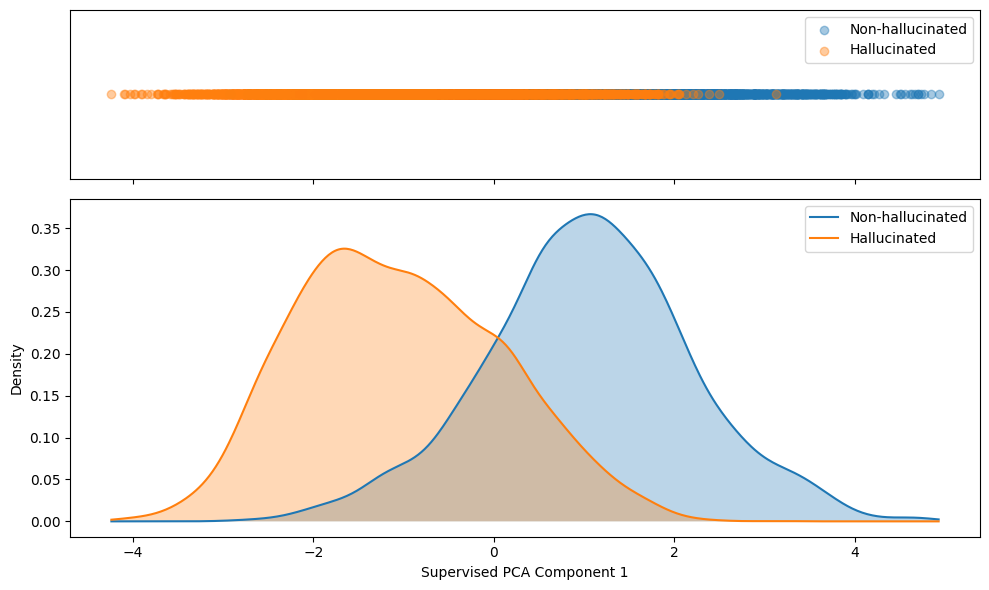

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

L = label_kernel(y_train)


Z_tr, Z_te, U = supervised_pca(X_train.T, L, X_test=X_test.T, n_components=1)



Z_tr_np = Z_tr.squeeze().cpu().numpy()
y_np    = y_train.cpu().numpy()

z0 = Z_tr_np[y_np == 0]
z1 = Z_tr_np[y_np == 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                gridspec_kw={"height_ratios": [1, 2]})

# ── Top: scatter ──────────────────────────────────────────────────────────────
ax1.scatter(z0, np.zeros(len(z0)), alpha=0.4, label="Non-hallucinated")
ax1.scatter(z1, np.zeros(len(z1)), alpha=0.4, label="Hallucinated")
ax1.set_yticks([])
ax1.legend()

# ── Bottom: KDE ───────────────────────────────────────────────────────────────
x_range = np.linspace(Z_tr_np.min(), Z_tr_np.max(), 500)

kde0 = gaussian_kde(z0)
kde1 = gaussian_kde(z1)

ax2.plot(x_range, kde0(x_range), label="Non-hallucinated")
ax2.plot(x_range, kde1(x_range), label="Hallucinated")
ax2.fill_between(x_range, kde0(x_range), alpha=0.3)
ax2.fill_between(x_range, kde1(x_range), alpha=0.3)
ax2.set_xlabel("Supervised PCA Component 1")
ax2.set_ylabel("Density")
ax2.legend()

plt.tight_layout()
plt.show()


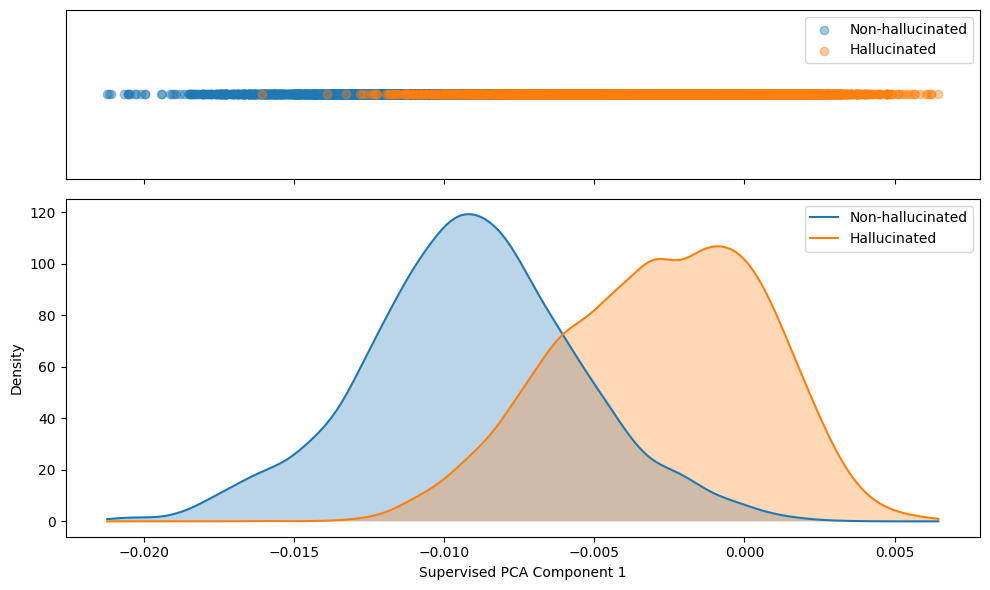

In [7]:


# Usage
project  = make_rff_projector(p=X_train.shape[1], rff_dim=6000, gamma=4.5e-6)

Phi_train = project(X_train).T   # (D, n)
Phi_test  = project(X_test).T    # (D, m)

Z_tr, Z_te, U = supervised_pca(Phi_train, L, X_test=Phi_test, n_components=1)


Z_tr_np = Z_tr.squeeze().cpu().numpy()
y_np    = y_train.cpu().numpy()

z0 = Z_tr_np[y_np == 0]
z1 = Z_tr_np[y_np == 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                gridspec_kw={"height_ratios": [1, 2]})

# ── Top: scatter ──────────────────────────────────────────────────────────────
ax1.scatter(z0, np.zeros(len(z0)), alpha=0.4, label="Non-hallucinated")
ax1.scatter(z1, np.zeros(len(z1)), alpha=0.4, label="Hallucinated")
ax1.set_yticks([])
ax1.legend()

# ── Bottom: KDE ───────────────────────────────────────────────────────────────
x_range = np.linspace(Z_tr_np.min(), Z_tr_np.max(), 500)

kde0 = gaussian_kde(z0)
kde1 = gaussian_kde(z1)

ax2.plot(x_range, kde0(x_range), label="Non-hallucinated")
ax2.plot(x_range, kde1(x_range), label="Hallucinated")
ax2.fill_between(x_range, kde0(x_range), alpha=0.3)
ax2.fill_between(x_range, kde1(x_range), alpha=0.3)
ax2.set_xlabel("Supervised PCA Component 1")
ax2.set_ylabel("Density")
ax2.legend()

plt.tight_layout()
plt.show()

/research/hal-afsharim/learn-to-steer/src/examples/milad/utils_milad.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, device=DEVICE)


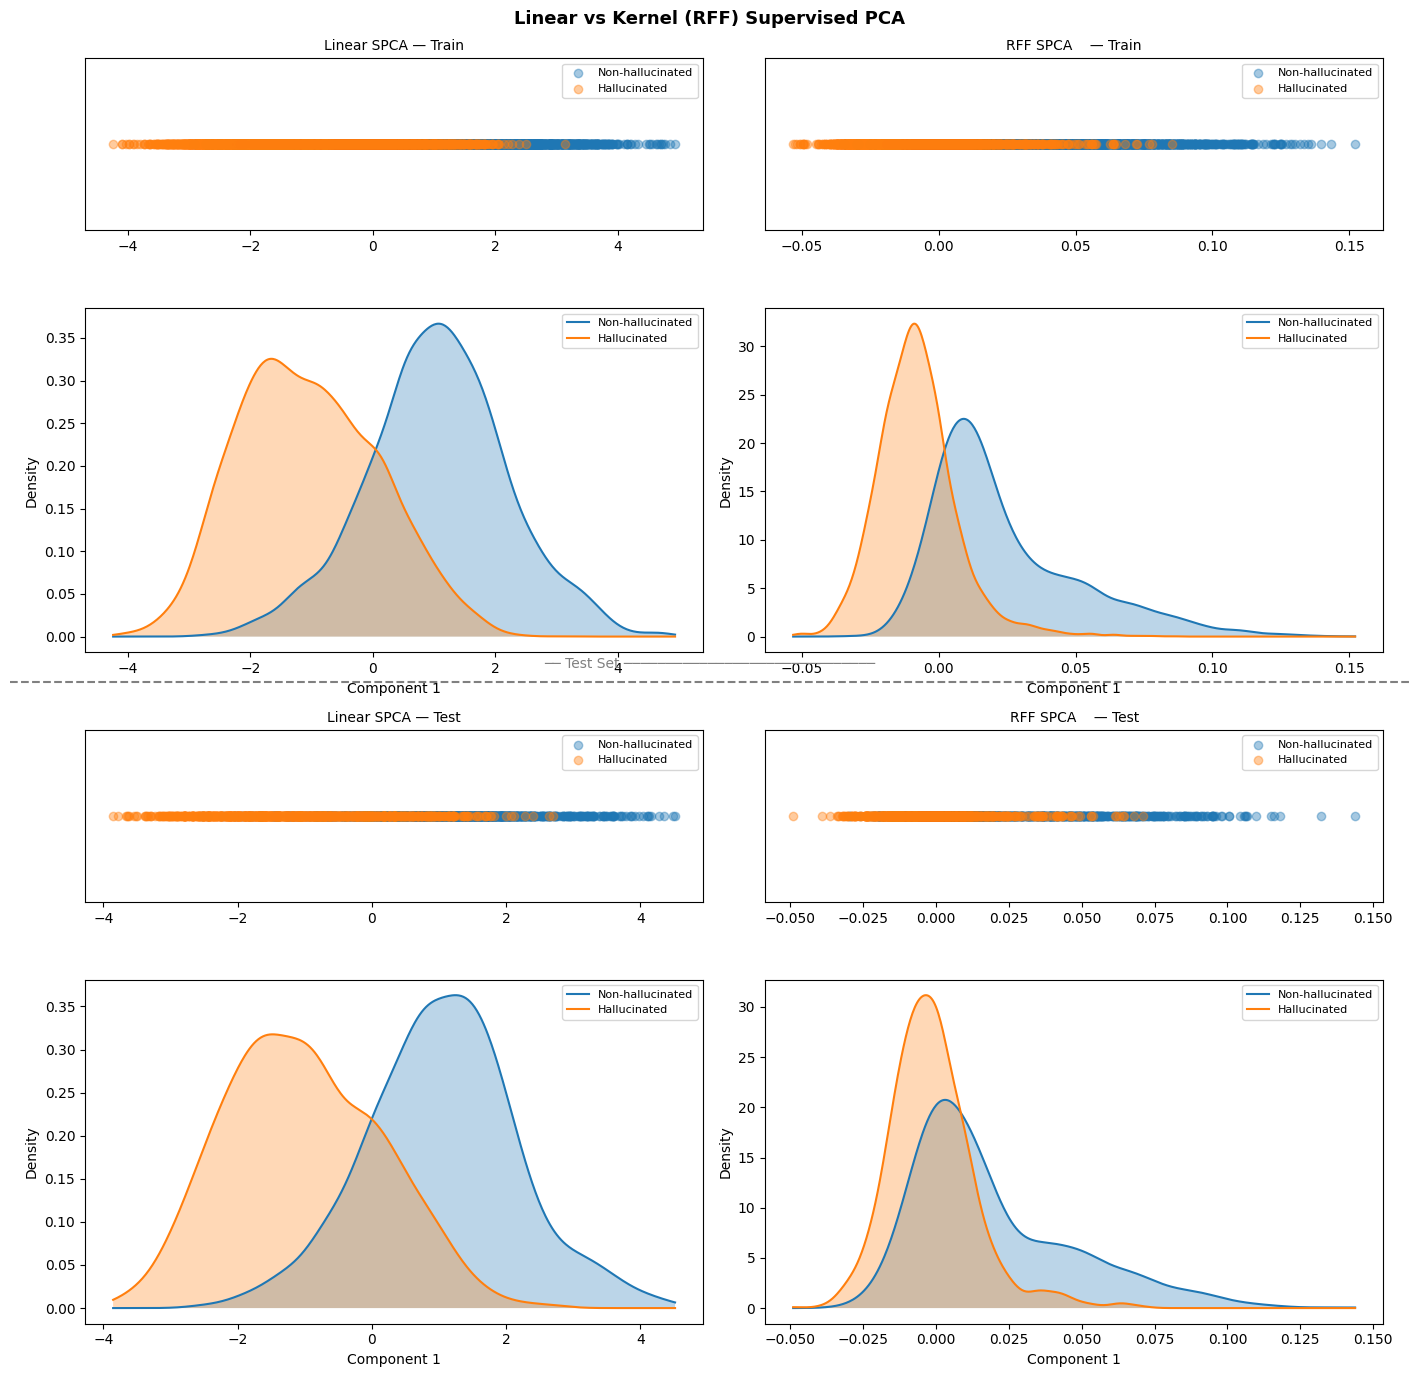

In [58]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

gamma = 7e-2


L      = label_kernel(y_train)
y_tr   = y_train.cpu().numpy()
y_te   = y_test.cpu().numpy()

# ── Run both methods ──────────────────────────────────────────────────────────

Z_tr_lin, Z_te_lin, U_lin = supervised_pca(X_train.T, L, X_test=X_test.T, n_components=1)

project        = make_rff_projector(p=X_train.shape[1], rff_dim=10000, gamma=gamma)
Phi_train      = project(X_train).T
Phi_test       = project(X_test).T
Z_tr_rff, Z_te_rff, U_rff = supervised_pca(Phi_train, L, X_test=Phi_test, n_components=1)

# ── Helper ────────────────────────────────────────────────────────────────────

def fill_axes(ax_scatter, ax_kde, Z, y, title):
    z  = Z.squeeze().cpu().numpy()
    z0 = z[y == 0]
    z1 = z[y == 1]

    ax_scatter.scatter(z0, np.zeros(len(z0)), alpha=0.4, label="Non-hallucinated")
    ax_scatter.scatter(z1, np.zeros(len(z1)), alpha=0.4, label="Hallucinated")
    ax_scatter.set_yticks([])
    ax_scatter.set_title(title, fontsize=10)
    ax_scatter.legend(fontsize=8)

    x_range     = np.linspace(z.min(), z.max(), 500)
    kde0, kde1  = gaussian_kde(z0), gaussian_kde(z1)
    ax_kde.plot(x_range, kde0(x_range), label="Non-hallucinated")
    ax_kde.plot(x_range, kde1(x_range), label="Hallucinated")
    ax_kde.fill_between(x_range, kde0(x_range), alpha=0.3)
    ax_kde.fill_between(x_range, kde1(x_range), alpha=0.3)
    ax_kde.set_xlabel("Component 1")
    ax_kde.set_ylabel("Density")
    ax_kde.legend(fontsize=8)

# ── 4×2 grid: rows = [train scatter, train kde, test scatter, test kde] ───────
#              cols = [linear, rff]

fig, axes = plt.subplots(4, 2, figsize=(14, 14),
                         gridspec_kw={"height_ratios": [1, 2, 1, 2]})

fill_axes(axes[0, 0], axes[1, 0], Z_tr_lin, y_tr, "Linear SPCA — Train")
fill_axes(axes[0, 1], axes[1, 1], Z_tr_rff, y_tr, "RFF SPCA    — Train")
fill_axes(axes[2, 0], axes[3, 0], Z_te_lin, y_te, "Linear SPCA — Test")
fill_axes(axes[2, 1], axes[3, 1], Z_te_rff, y_te, "RFF SPCA    — Test")

# link x-axes within each column so scales are comparable
for col in [0, 1]:
    axes[0, col].sharex(axes[1, col])
    axes[2, col].sharex(axes[3, col])

# dividing line between train and test sections
fig.add_artist(plt.Line2D([0, 1], [0.5, 0.5],
               transform=fig.transFigure, color="gray",
               linewidth=1.5, linestyle="--"))

fig.text(0.5, 0.97, "Linear vs Kernel (RFF) Supervised PCA",
         ha="center", fontsize=13, fontweight="bold")
fig.text(0.5, 0.51, "── Test Set ──────────────────────────────",
         ha="center", fontsize=10, color="gray")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Calibrating step size...
  step_size=100.00  z: 0.0088 → 0.2604  Δz=0.251658
  step_size= 10.00  z: 0.0088 → 0.0515  Δz=0.042677
  step_size=  1.00  z: 0.0088 → 0.0131  Δz=0.004289
  step_size=  0.10  z: 0.0088 → 0.0091  Δz=0.000338
  step_size=  0.01  z: 0.0088 → 0.0088  Δz=0.000005

z_mean at start: 0.0088,  z_target: 0.0600
step 000  loss=8.1483  z_mean=0.0088  gap=0.0512  x_drift=10.0000
step 050  loss=2.3974  z_mean=0.0864  gap=0.0264  x_drift=29.8594
step 100  loss=0.6813  z_mean=0.0725  gap=0.0125  x_drift=58.3438
step 150  loss=0.0995  z_mean=0.0638  gap=0.0038  x_drift=81.2500
Converged at step 190

z_mean: 0.0088 → 0.0602  (target=0.0600)


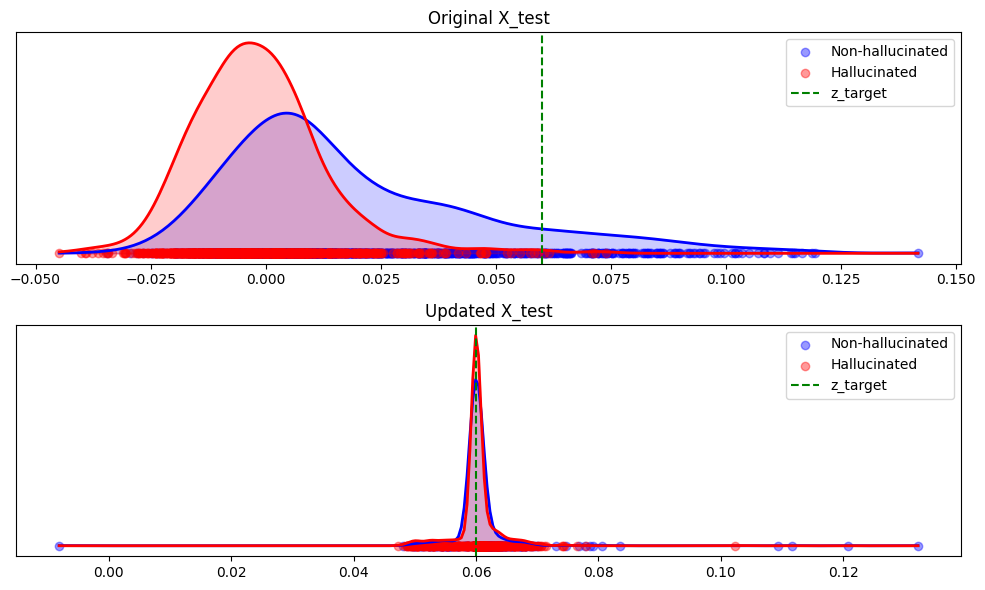

In [10]:


# ── Step 1: Build the encoder from your already-fitted objects ────────────────
# Assumes you already have:
#   project  — from make_rff_projector(...)
#   U        — from supervised_pca(Phi_train, L, ...) 

def encode(x, project, U):
    """
    x       : (n, p)  input embeddings
    returns : (n, 1)  latent coordinates
    """
    phi = project(x)          # (n, D)  — RFF features
    z   = phi @ U             # (n, 1)  — project onto supervised direction
    return z


# ── Step 2: Pick a target z ───────────────────────────────────────────────────
# e.g. move toward the mean of class 1 (hallucinated) in latent space

Z_tr_np   = encode(X_train, project, U_rff)
z_target  = torch.tensor(0.06)  # (1, 1)


def gradient_step(x_old, z_target, project, U, step_size=1.0):
    x = x_old.clone().detach().requires_grad_(True)

    z    = encode(x, project, U)
    loss = ((z - z_target) ** 2).sum()
    loss.backward()

    with torch.no_grad():
        # normalize gradient to unit norm, then scale by step_size
        grad = x.grad
        grad = grad / (grad.norm() + 1e-8)
        x_new = x_old - step_size * grad

        # safety check
        if torch.isnan(x_new).any():
            print("NaN detected — reducing step size")
            return x_old, loss.item(), encode(x_old, project, U).detach().mean().item()

    return x_new, loss.item(), z.detach().mean().item()


# ── Find a good step_size first ───────────────────────────────────────────────
print("Calibrating step size...")
for step_size in [100.0, 10.0, 1.0, 0.1, 0.01]:
    x_probe = X_test.clone()
    x_new_probe, _, _ = gradient_step(x_probe, z_target, project, U_rff, step_size)
    z_before = encode(X_test,      project, U_rff).detach().mean().item()
    z_after  = encode(x_new_probe, project, U_rff).detach().mean().item()
    print(f"  step_size={step_size:6.2f}  z: {z_before:.4f} → {z_after:.4f}  "
          f"Δz={z_after - z_before:.6f}")


# ── Run with the best step_size ───────────────────────────────────────────────
# Pick whichever step_size above gave the largest Δz without NaN
STEP_SIZE = 10.0   # adjust based on calibration output above

x_old  = X_test.clone()
z_init = encode(X_test, project, U_rff).detach().mean().item()
print(f"\nz_mean at start: {z_init:.4f},  z_target: {z_target:.4f}")

for step in range(500):
    x_new, loss, z_mean = gradient_step(x_old, z_target, project, U_rff, STEP_SIZE)
    x_old = x_new

    if step % 50 == 0:
        drift = (x_new - X_test).norm().item()
        gap   = abs(z_target - z_mean)
        print(f"step {step:03d}  loss={loss:.4f}  z_mean={z_mean:.4f}  "
              f"gap={gap:.4f}  x_drift={drift:.4f}")

    if abs(z_mean - z_target) < 1e-4:
        print(f"Converged at step {step}")
        break

z_final = encode(x_new, project, U_rff).detach().mean().item()
print(f"\nz_mean: {z_init:.4f} → {z_final:.4f}  (target={z_target:.4f})")
# ── Step 4: Run a few steps and watch z move ──────────────────────────────────



# ── Step 5: Verify — plot original vs updated representations ─────────────────

z_original = encode(X_test,  project, U_rff).squeeze().detach().cpu().numpy()
z_updated  = encode(x_new,   project, U_rff).squeeze().detach().cpu().numpy()
y_te       = y_test.cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)

for ax, z, title in zip(axes,
                         [z_original, z_updated],
                         ["Original X_test", "Updated X_test"]):
    for cls, color, label in [(0, "blue", "Non-hallucinated"),
                               (1, "red",  "Hallucinated")]:
        zc = z[y_te == cls]
        ax.scatter(zc, np.zeros(len(zc)), alpha=0.4, color=color, label=label)
        if len(zc) > 1:
            x_range = np.linspace(z.min(), z.max(), 300)
            kde = gaussian_kde(zc)
            ax.plot(x_range, kde(x_range), color=color, lw=2)
            ax.fill_between(x_range, kde(x_range), alpha=0.2, color=color)
    ax.axvline(z_target.item(), color="green", linestyle="--", label="z_target")
    ax.set_title(title)
    ax.set_yticks([])
    ax.legend()

plt.tight_layout()
plt.show()


In [48]:
x_new.shape

torch.Size([2520, 4096])

Class 0 mean (train): 0.0236
Class 1 mean (train): -0.0089
Threshold (midpoint): 0.0073
z_target (cls1 mean): 0.0540

Test samples needing shift: 1522 / 2520
z_mean test (all):          0.0088
z_mean test (needs shift):  -0.0059
step 000  loss=5.5804  z_mean=-0.0059  threshold=0.0073
Converged at step 1

── Results on TEST set ──────────────────────────────────────
Threshold (from train):          0.0073
z_mean before (shifted group):   -0.0059
z_mean after  (shifted group):   0.0398
z_mean before (unchanged group): 0.0312
z_mean after  (unchanged group): 0.0312


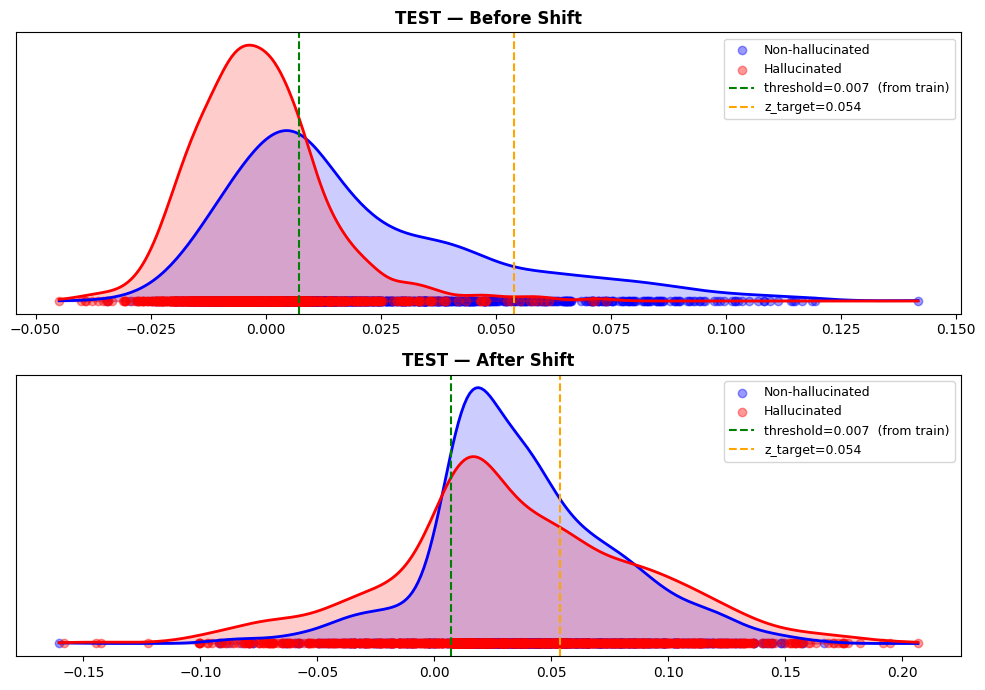

In [22]:
X_test = X_test.to(DEVICE)
X_train = X_train.to(DEVICE)

STEP_SIZE = 10.0
z_target  = torch.tensor(0.05, device=DEVICE)

# ── Step 1: Fit threshold on TRAIN data ───────────────────────────────────────
z_train = encode(X_train, project, U_rff).detach().squeeze()   # (n_train,)
y_tr    = y_train.to(DEVICE)

# Threshold = midpoint between the two class means in latent space
z_mean_cls0 = z_train[y_tr == 0].mean()
z_mean_cls1 = z_train[y_tr == 1].mean()
THRESHOLD   = ((z_mean_cls0 + z_mean_cls1) / 2).item()

print(f"Class 0 mean (train): {z_mean_cls0.item():.4f}")
print(f"Class 1 mean (train): {z_mean_cls1.item():.4f}")
print(f"Threshold (midpoint): {THRESHOLD:.4f}")

# Which class is "above" threshold? (i.e. the target class to shift toward)
z_target = torch.tensor(0.054, device=DEVICE)
print(f"z_target (cls1 mean): {z_target.item():.4f}")


# ── Step 2: Observe test data BEFORE any shift ────────────────────────────────
z_test_init  = encode(X_test, project, U_rff).detach().squeeze()   # (n_test,)
needs_shift = (z_test_init < THRESHOLD).to(DEVICE)   # ← add this

print(f"\nTest samples needing shift: {needs_shift.sum().item()} / {len(needs_shift)}")
print(f"z_mean test (all):          {z_test_init.mean().item():.4f}")
print(f"z_mean test (needs shift):  {z_test_init[needs_shift].mean().item():.4f}")


# ── Step 3: Shift only the flagged TEST samples ───────────────────────────────
def gradient_step(x_old, z_target, project, U, step_size=10.0):
    x    = x_old.clone().detach().requires_grad_(True)
    z    = encode(x, project, U)
    loss = ((z - z_target) ** 2).sum()
    loss.backward()

    with torch.no_grad():
        grad  = x.grad / (x.grad.norm() + 1e-8)
        x_new = x_old - step_size * grad

    return x_new, loss.item(), z.detach().squeeze()


x_to_shift = X_test[needs_shift].clone()

for step in range(500):
    x_to_shift, loss, z_shifted = gradient_step(
        x_to_shift, z_target, project, U_rff, STEP_SIZE
    )

    if step % 50 == 0:
        print(f"step {step:03d}  loss={loss:.4f}  "
              f"z_mean={z_shifted.mean().item():.4f}  "
              f"threshold={THRESHOLD:.4f}")

    if z_shifted.mean().item() >= THRESHOLD:
        print(f"Converged at step {step}")
        break


# ── Step 4: Reconstruct full test set ─────────────────────────────────────────
x_new = X_test.clone()
x_new[needs_shift] = x_to_shift

z_test_final = encode(x_new, project, U_rff).detach().squeeze()


# ── Step 5: Report ────────────────────────────────────────────────────────────
print(f"\n── Results on TEST set ──────────────────────────────────────")
print(f"Threshold (from train):          {THRESHOLD:.4f}")
print(f"z_mean before (shifted group):   {z_test_init[needs_shift].mean().item():.4f}")
print(f"z_mean after  (shifted group):   {z_test_final[needs_shift].mean().item():.4f}")
print(f"z_mean before (unchanged group): {z_test_init[~needs_shift].mean().item():.4f}")
print(f"z_mean after  (unchanged group): {z_test_final[~needs_shift].mean().item():.4f}")


# ── Step 6: Plot ──────────────────────────────────────────────────────────────
z_init_np  = z_test_init.cpu().numpy()
z_final_np = z_test_final.cpu().numpy()
y_te       = y_test.cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

for ax, z, title in zip(axes,
                         [z_init_np, z_final_np],
                         ["TEST — Before Shift", "TEST — After Shift"]):
    for cls, color, label in [(0, "blue", "Non-hallucinated"),
                               (1, "red",  "Hallucinated")]:
        zc = z[y_te == cls]
        ax.scatter(zc, np.zeros(len(zc)), alpha=0.4, color=color, label=label)
        if len(zc) > 1:
            x_range = np.linspace(z.min(), z.max(), 300)
            kde = gaussian_kde(zc)
            ax.plot(x_range, kde(x_range), color=color, lw=2)
            ax.fill_between(x_range, kde(x_range), alpha=0.2, color=color)

    ax.axvline(THRESHOLD,       color="green",  linestyle="--",
               label=f"threshold={THRESHOLD:.3f}  (from train)")
    ax.axvline(z_target.item(), color="orange", linestyle="--",
               label=f"z_target={z_target.item():.3f}")
    ax.set_yticks([])
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [63]:
lin_shift = non_hal_features - hal_features

print(torch.norm(lin_shift, dim=1))
print(torch.norm(non_hal_features, dim=1))
print(torch.norm(hal_features, dim=1))






tensor([12.2500, 14.6406, 11.4375,  ..., 10.4297,  9.9375, 10.1562],
       dtype=torch.float16)
tensor([16.5000, 15.6875, 14.9219,  ..., 15.3125, 16.8594, 14.4766],
       dtype=torch.float16)
tensor([16.0781, 17.5312, 15.0156,  ..., 16.0000, 16.0781, 17.2188],
       dtype=torch.float16)


Class 0 mean (train): 0.0236
Class 1 mean (train): -0.0089
Threshold (midpoint): 0.0000
z_target:             0.0550

Train samples needing shift: 4699 / 10080
Test samples needing shift:  1051 / 2520

--- Shifting TRAIN ---
step 000  loss=22.3213  z_mean=-0.0133  threshold=0.0000
Converged at step 1

--- Shifting TEST ---
step 000  loss=4.5160  z_mean=-0.0101  threshold=0.0000
Converged at step 1

── Results on TRAIN set ──────────────────────────────────────
z_mean before (shifted group):   -0.0133
z_mean after  (shifted group):   0.0556
z_mean before (unchanged group): 0.0253
z_mean after  (unchanged group): 0.0253

── Results on TEST set ──────────────────────────────────────
z_mean before (shifted group):   -0.0101
z_mean after  (shifted group):   -0.0073
z_mean before (unchanged group): 0.0223
z_mean after  (unchanged group): 0.0223


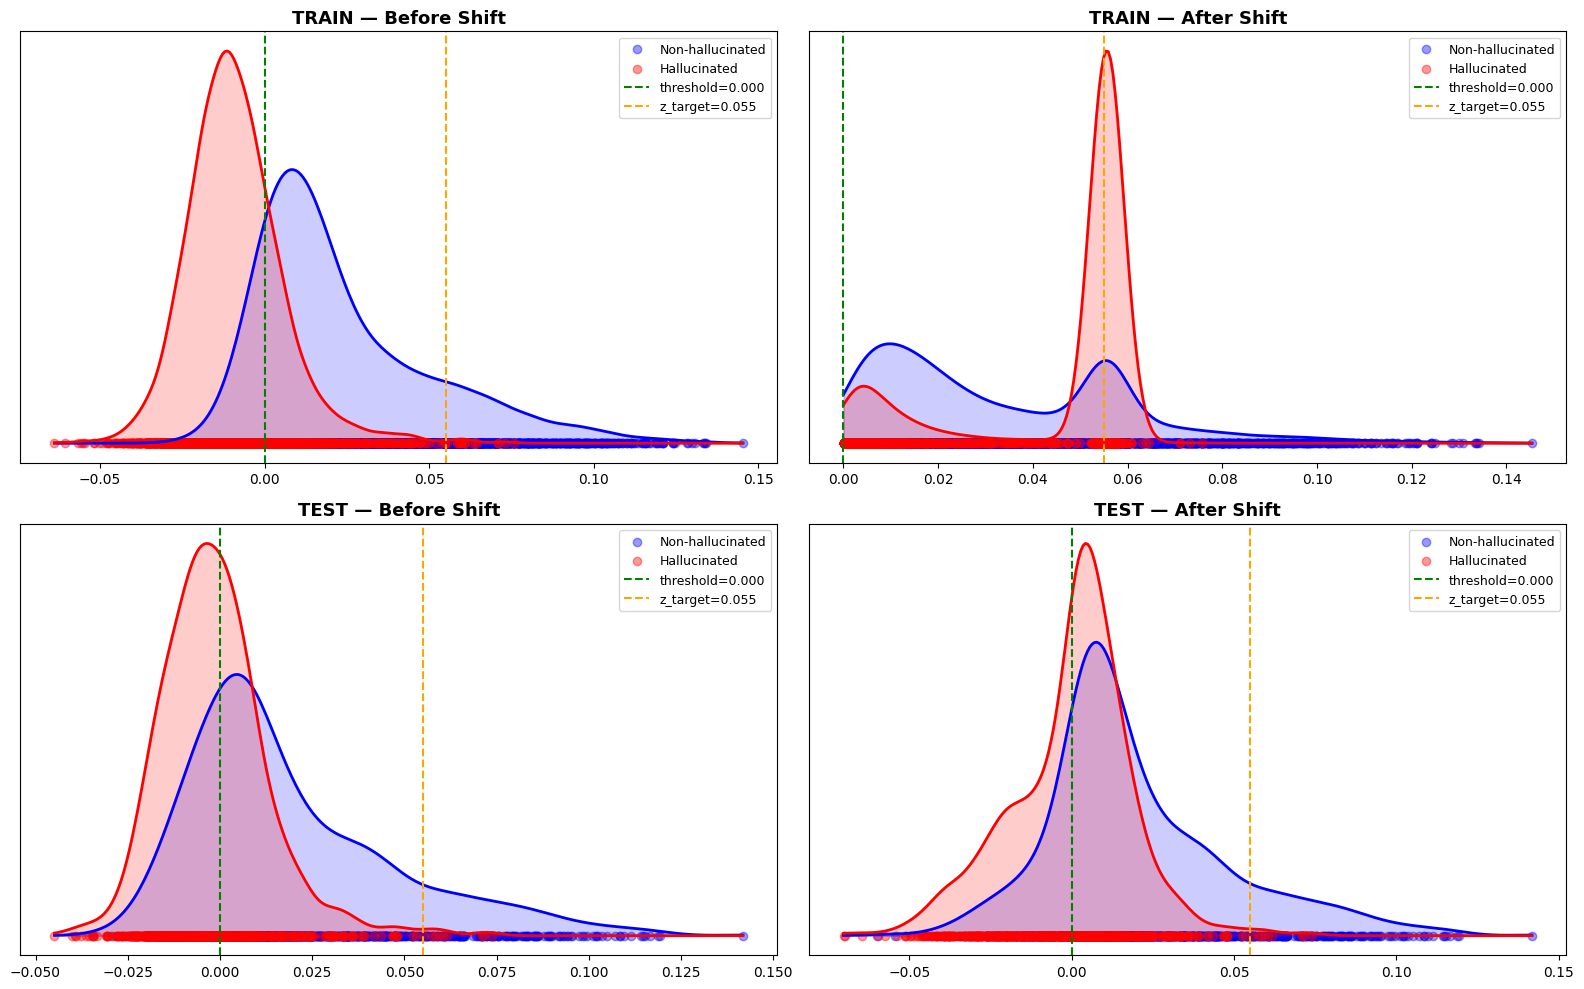

In [36]:
# Ensure inputs are on the correct device
X_test = X_test.to(DEVICE)
X_train = X_train.to(DEVICE)
y_tr = y_train.to(DEVICE)
y_te = y_test.to(DEVICE)

STEP_SIZE = 10.0

# ── Step 1: Fit threshold on TRAIN data ───────────────────────────────────────
z_train_init = encode(X_train, project, U_rff).detach().squeeze()   # (n_train,)

# Threshold = midpoint between the two class means in latent space
z_mean_cls0 = z_train_init[y_tr == 0].mean()
z_mean_cls1 = z_train_init[y_tr == 1].mean()
# THRESHOLD   = ((z_mean_cls0 + z_mean_cls1) / 2).item()
THRESHOLD = 0.0

print(f"Class 0 mean (train): {z_mean_cls0.item():.4f}")
print(f"Class 1 mean (train): {z_mean_cls1.item():.4f}")
print(f"Threshold (midpoint): {THRESHOLD:.4f}")

# Which class is "above" threshold? (i.e. the target class to shift toward)
z_target = torch.tensor(0.055, device=DEVICE)
print(f"z_target:             {z_target.item():.4f}")


# ── Step 2: Observe data BEFORE any shift ─────────────────────────────────────
z_test_init = encode(X_test, project, U_rff).detach().squeeze()   # (n_test,)

needs_shift_train = (z_train_init < THRESHOLD).to(DEVICE)
needs_shift_test  = (z_test_init < THRESHOLD).to(DEVICE)

print(f"\nTrain samples needing shift: {needs_shift_train.sum().item()} / {len(needs_shift_train)}")
print(f"Test samples needing shift:  {needs_shift_test.sum().item()} / {len(needs_shift_test)}")



# ── Step 3: Define gradient step & shift function ─────────────────────────────
def gradient_step(x_old, z_target, project, U, step_size=10.0):
    x    = x_old.clone().detach().requires_grad_(True)
    z    = encode(x, project, U)
    loss = ((z - z_target) ** 2).sum()
    loss.backward()

    with torch.no_grad():
        grad  = x.grad / (x.grad.norm() + 1e-8)
        x_new = x_old - step_size * grad

    return x_new, loss.item(), z.detach().squeeze()

def apply_shift(X_original, needs_shift_mask, z_target, project, U, step_size, threshold, name="Data"):
    if needs_shift_mask.sum() == 0:
        print(f"{name}: No samples need shifting.")
        return X_original.clone(), encode(X_original, project, U).detach().squeeze()

    x_to_shift = X_original[needs_shift_mask].clone()
    print(f"\n--- Shifting {name} ---")
    
    for step in range(500):
        x_to_shift, loss, z_shifted = gradient_step(
            x_to_shift, z_target, project, U, step_size
        )

        if step % 50 == 0:
            print(f"step {step:03d}  loss={loss:.4f}  "
                  f"z_mean={z_shifted.mean().item():.4f}  "
                  f"threshold={threshold:.4f}")

        if z_shifted.mean().item() >= threshold:
            print(f"Converged at step {step}")
            break

    # Reconstruct full dataset
    x_new = X_original.clone()
    x_new[needs_shift_mask] = x_to_shift
    z_final = encode(x_new, project, U).detach().squeeze()
    
    return x_new, z_final

# Apply to Train
X_train_new, z_train_final = apply_shift(
    X_train, needs_shift_train, z_target, project, U_rff, STEP_SIZE, THRESHOLD, name="TRAIN"
)

# Apply to Test
X_test_new, z_test_final = apply_shift(
    X_test, needs_shift_test, z_target, project, U_rff, STEP_SIZE, THRESHOLD, name="TEST"
)


# ── Step 4: Report ────────────────────────────────────────────────────────────
def report_stats(z_init, z_final, needs_shift, name=""):
    print(f"\n── Results on {name} set ──────────────────────────────────────")
    print(f"z_mean before (shifted group):   {z_init[needs_shift].mean().item():.4f}")
    print(f"z_mean after  (shifted group):   {z_final[needs_shift].mean().item():.4f}")
    print(f"z_mean before (unchanged group): {z_init[~needs_shift].mean().item():.4f}")
    print(f"z_mean after  (unchanged group): {z_final[~needs_shift].mean().item():.4f}")

report_stats(z_train_init, z_train_final, needs_shift_train, name="TRAIN")
report_stats(z_test_init, z_test_final, needs_shift_test, name="TEST")


# ── Step 5: Plot ──────────────────────────────────────────────────────────────
# Convert to numpy for matplotlib
z_train_init_np  = z_train_init.cpu().numpy()
z_train_final_np = z_train_final.cpu().numpy()
z_test_init_np   = z_test_init.cpu().numpy()
z_test_final_np  = z_test_final.cpu().numpy()
y_tr_np          = y_tr.cpu().numpy()
y_te_np          = y_te.cpu().numpy()

# Set up a 2x2 grid (Row 1: Train, Row 2: Test)
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)

plot_configs = [
    (axes[0, 0], z_train_init_np,  y_tr_np, "TRAIN — Before Shift"),
    (axes[0, 1], z_train_final_np, y_tr_np, "TRAIN — After Shift"),
    (axes[1, 0], z_test_init_np,   y_te_np, "TEST — Before Shift"),
    (axes[1, 1], z_test_final_np,  y_te_np, "TEST — After Shift")
]

for ax, z_data, y_labels, title in plot_configs:
    for cls, color, label in [(0, "blue", "Non-hallucinated"),
                               (1, "red",  "Hallucinated")]:
        zc = z_data[y_labels == cls]
        ax.scatter(zc, np.zeros(len(zc)), alpha=0.4, color=color, label=label)
        
        # Only draw KDE if there's enough variance/data points
        if len(zc) > 1 and zc.std() > 1e-6: 
            x_range = np.linspace(z_data.min(), z_data.max(), 300)
            kde = gaussian_kde(zc)
            ax.plot(x_range, kde(x_range), color=color, lw=2)
            ax.fill_between(x_range, kde(x_range), alpha=0.2, color=color)

    ax.axvline(THRESHOLD,       color="green",  linestyle="--",
               label=f"threshold={THRESHOLD:.3f}")
    ax.axvline(z_target.item(), color="orange", linestyle="--",
               label=f"z_target={z_target.item():.3f}")
    
    ax.set_yticks([])
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

In [47]:
# ── Step 3: Find Optimal Hyperparameters on TRAIN Data ────────────────────────
def gradient_step(x_old, z_target, project, U, step_size):
    x    = x_old.clone().detach().requires_grad_(True)
    z    = encode(x, project, U)
    loss = ((z - z_target) ** 2).sum()
    loss.backward()

    with torch.no_grad():
        grad  = x.grad / (x.grad.norm() + 1e-8)
        x_new = x_old - step_size * grad

    return x_new, loss.item(), z.detach().squeeze()

print("\n── Tuning Step Size and Iterations on TRAIN data ──")
candidate_step_sizes = [0.1, 1.0, 5.0, 10.0, 25.0, 50.0, 100.0]
max_search_steps = 1000

best_step_size = None
optimal_iterations = None
min_steps = float('inf')

x_train_to_shift = X_train[needs_shift_train].clone()

for test_step_size in candidate_step_sizes:
    x_temp = x_train_to_shift.clone()
    converged = False
    
    for step in range(1, max_search_steps + 1):
        x_temp, loss, z_temp = gradient_step(x_temp, z_target, project, U_rff, test_step_size)
        
        # Failsafe: check for divergence
        if torch.isnan(z_temp).any() or loss > 1e6:
            print(f"Step size {test_step_size:5.1f}: Diverged/Exploded at step {step}")
            break
            
        # Success condition
        if z_temp.mean().item() >= THRESHOLD:
            print(f"Step size {test_step_size:5.1f}: Converged in {step:3d} iterations (Loss: {loss:.4f})")
            converged = True
            
            # Save the fastest stable configuration
            if step < min_steps:
                min_steps = step
                best_step_size = test_step_size
                optimal_iterations = step
            break
            
    if not converged and not torch.isnan(z_temp).any():
         print(f"Step size {test_step_size:5.1f}: Failed to converge within {max_search_steps} iterations.")

print(f"\n✅ Optimal Configuration Found:")
print(f"   Step Size:  {best_step_size}")
print(f"   Iterations: {optimal_iterations}")


# ── Step 4: Apply the deterministic shift to TEST Data ────────────────────────
def apply_deterministic_shift(X_original, needs_shift_mask, z_target, project, U, step_size, iterations, name="Data"):
    if needs_shift_mask.sum() == 0:
        print(f"{name}: No samples need shifting.")
        return X_original.clone(), encode(X_original, project, U).detach().squeeze()

    x_to_shift = X_original[needs_shift_mask].clone()
    print(f"\n--- Shifting {name} using fixed parameters ---")
    
    # We no longer check for threshold convergence here. 
    # We just rigidly apply the optimal iterations we found on the train set.
    for step in range(iterations):
        x_to_shift, loss, z_shifted = gradient_step(x_to_shift, z_target, project, U, step_size)

    print(f"{name} shift complete. Final loss: {loss:.4f}, Final z_mean: {z_shifted.mean().item():.4f}")

    # Reconstruct full dataset
    x_new = X_original.clone()
    x_new[needs_shift_mask] = x_to_shift
    z_final = encode(x_new, project, U).detach().squeeze()
    
    return x_new, z_final

# We must also apply it to the Train set to get our final X_train_new for downstream use
X_train_new, z_train_final = apply_deterministic_shift(
    X_train, needs_shift_train, z_target, project, U_rff, best_step_size, optimal_iterations, name="TRAIN"
)

# Apply to Test using the EXACT same hyperparameters learned from Train
X_test_new, z_test_final = apply_deterministic_shift(
    X_test, needs_shift_test, z_target, project, U_rff, best_step_size, optimal_iterations, name="TEST"
)


── Tuning Step Size and Iterations on TRAIN data ──
Step size   0.1: Converged in  62 iterations (Loss: 14.3522)
Step size   1.0: Converged in   5 iterations (Loss: 14.1924)
Step size   5.0: Converged in   2 iterations (Loss: 12.4460)
Step size  10.0: Converged in   2 iterations (Loss: 5.4523)
Step size  25.0: Converged in   2 iterations (Loss: 1.4147)
Step size  50.0: Converged in   2 iterations (Loss: 42.9925)
Step size 100.0: Converged in   2 iterations (Loss: 196.1127)

✅ Optimal Configuration Found:
   Step Size:  5.0
   Iterations: 2

--- Shifting TRAIN using fixed parameters ---
TRAIN shift complete. Final loss: 12.4460, Final z_mean: 0.0040

--- Shifting TEST using fixed parameters ---
TEST shift complete. Final loss: 0.8674, Final z_mean: 0.0265


In [85]:
import torch.optim as optim

# 1. Isolate the hallucinated training data (Keep it FROZEN)
x_train_hallu = X_train[needs_shift_train].clone().detach() # No requires_grad here!

# 2. Initialize the Shift Vector (This is what we are learning)
# It starts as all zeros, and has the same dimension as your embeddings
delta = torch.zeros(X_train.shape[1], device=DEVICE, requires_grad=True)

# Use standard Adam optimizer for the shift vector
optimizer = optim.Adam([delta], lr=0.01)

# Hyperparameter to keep the shift small (prevents garbage generation)
# Increase this if Cosine Similarity drops too low!
LAMBDA_PENALTY = 1e-6

print("── Learning the Universal Shift Vector (TRAIN DATA) ──")
for step in range(500):
    optimizer.zero_grad()
    
    # Apply our current guess for the shift to ALL hallucinated train samples
    x_shifted = x_train_hallu + delta
    
    # See where they land in the RKHS
    z_shifted = encode(x_shifted, project, U_rff).squeeze()
    
    # Calculate how far we are from the target
    rkhs_loss = ((z_shifted - z_target) ** 2).mean()
    
    # Calculate how massive our shift vector is getting
    magnitude_loss = LAMBDA_PENALTY * (delta.norm() ** 2)
    
    # Total loss
    loss = rkhs_loss + magnitude_loss
    loss.backward()
    optimizer.step()
    
    if step % 50 == 0:
        print(f"Step {step:03d} | Total Loss: {loss.item():.4f} | "
              f"z_mean: {z_shifted.mean().item():.4f} | delta norm: {delta.norm().item():.4f}")

    # Stop if the average point crosses the threshold safely
    if z_shifted.mean().item() >= THRESHOLD:
        print(f"✅ Learned optimal shift vector at step {step}!")
        break

# Detach delta so it's just a static vector now
learned_delta = delta.detach()
print(f"Final Shift Magnitude (L2): {learned_delta.norm().item():.4f}")

── Learning the Universal Shift Vector (TRAIN DATA) ──
Step 000 | Total Loss: 0.0041 | z_mean: -0.0079 | delta norm: 0.6376
✅ Learned optimal shift vector at step 3!
Final Shift Magnitude (L2): 2.1998


In [82]:
delta.cpu().detach()

tensor([ 0.0331,  0.0379, -0.0388,  ...,  0.0389,  0.0382,  0.0357])

In [84]:
torch.norm(delta.cpu().detach())

tensor(2.1860)

In [5]:
import torch
test_data = torch.load("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/features/save_hidden_states_llava_pope_test_features_normal_14_popular_10_milad.pth")
test_data.keys()

dict_keys(['response', 'image', 'model_predictions', 'hidden_states'])

In [6]:
test_data["hidden_states"]

[{'language_model.model.layers.14': tensor([[[ 0.3196, -1.5879,  0.5317,  ..., -0.3726, -0.8574, -0.0143],
           [ 0.3940,  0.2458,  0.2632,  ...,  0.1758, -0.1592, -0.2871],
           [ 0.1884,  0.6626,  0.2168,  ..., -0.2036,  0.0257, -0.3586],
           ...,
           [-0.3770, -0.1047,  0.5615,  ...,  0.1096,  0.4143, -0.8950],
           [-0.4458,  0.7734,  0.2080,  ...,  0.1627, -0.3169, -0.4646],
           [ 0.1145,  0.0753,  0.2396,  ...,  0.0103, -0.1136,  0.3281]]],
         dtype=torch.float16)},
 {'language_model.model.layers.14': tensor([[[ 0.3196, -1.5879,  0.5317,  ..., -0.3726, -0.8574, -0.0143],
           [ 0.3940,  0.2458,  0.2632,  ...,  0.1758, -0.1592, -0.2871],
           [ 0.1884,  0.6626,  0.2168,  ..., -0.2036,  0.0257, -0.3586],
           ...,
           [-0.0373, -0.1024,  0.2485,  ..., -0.0706, -0.0065, -0.2244],
           [-0.0105, -0.2856,  0.1963,  ..., -0.4587,  0.0886, -0.2798],
           [-0.0121,  0.1702,  0.0144,  ...,  0.1230,  0.3333, 

In [4]:
import sys, torch
sys.path.append("/research/hal-afsharim/learn-to-steer/src")

from models import get_model_class

class Args:
    model_name_or_path = "llava-hf/llava-1.5-7b-hf"
    processor_name = None
    cache_dir = None
    local_files_only = False
    prompt_template = "llava"

args = Args()

mc = get_model_class(
    args.model_name_or_path,
    args.processor_name,
    device=torch.device("cpu"),
    args=args,
)

names = [n for n, _ in mc.model_.named_modules()]

print("=== names containing 'layers.14' ===")
for n in names:
    if "layers.14" in n:
        print(n)

/research/hal-afsharim/miniconda3/envs/xl_vlm/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/research/hal-afsharim/miniconda3/envs/xl_vlm/lib/python3.9/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  6.30it/s]


=== names containing 'layers.14' ===
vision_tower.vision_model.encoder.layers.14
vision_tower.vision_model.encoder.layers.14.self_attn
vision_tower.vision_model.encoder.layers.14.self_attn.k_proj
vision_tower.vision_model.encoder.layers.14.self_attn.v_proj
vision_tower.vision_model.encoder.layers.14.self_attn.q_proj
vision_tower.vision_model.encoder.layers.14.self_attn.out_proj
vision_tower.vision_model.encoder.layers.14.layer_norm1
vision_tower.vision_model.encoder.layers.14.mlp
vision_tower.vision_model.encoder.layers.14.mlp.activation_fn
vision_tower.vision_model.encoder.layers.14.mlp.fc1
vision_tower.vision_model.encoder.layers.14.mlp.fc2
vision_tower.vision_model.encoder.layers.14.layer_norm2
language_model.model.layers.14
language_model.model.layers.14.self_attn
language_model.model.layers.14.self_attn.q_proj
language_model.model.layers.14.self_attn.k_proj
language_model.model.layers.14.self_attn.v_proj
language_model.model.layers.14.self_attn.o_proj
language_model.model.layers.1

In [48]:
X_test_new.shape

torch.Size([2520, 4096])

In [37]:
mean_shift = torch.load("/research/hal-afsharim/learn-to-steer/Hallucination/POPE/hallucination/shift_vectors/llava_14_average_all_pope_train_-1_mean.pth")

mean_shift.keys()

dict_keys(['steering_vector'])

In [46]:
(mean_shift["steering_vector"][0]==mean_shift["steering_vector"][1]).all()

tensor(True)